# EV Charging Station Demand Forecasting

**Goal:** Forecast daily energy demand (kWh) at EV charging stations using historical session data.

**Project timeline:** 3-4 day sprint
- Day 1: Load & explore data, define goal
- Day 2: Clean data, EDA (trend/seasonality)
- Day 3: Baseline model + evaluation
- Day 4: Stronger model + visualizations + polish

---

**Note on data:** This notebook starts with a synthetic EV charging dataset generated to mimic the structure of real-world datasets (e.g. the Kaggle "EV Charging Station Usage - California City" dataset: session_id, station_id, start_time, end_time, kwh_total, etc.).

**If you have the real Kaggle CSV**, drop it in the same folder as this notebook, rename it to `ev_sessions.csv`, and re-run — the loading cell below will automatically use it instead of synthetic data if it finds the file.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

## 1. Load Data

Tries to load a real dataset (`ev_sessions.csv`) if present, otherwise generates a realistic synthetic one so the pipeline can run end-to-end today.

In [ ]:
DATA_PATH = "ev_sessions.csv"

def generate_synthetic_ev_data(n_days=365, stations=15, seed=42):
    """Generate synthetic EV charging session data with realistic patterns:
    - Weekly seasonality (weekday commuter charging > weekends)
    - Yearly seasonality (more charging in colder months - heating draw + shorter days)
    - Overall upward trend (EV adoption growing over the year)
    - Random noise + occasional outlier sessions
    """
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2023-01-01", periods=n_days, freq="D")
    sessions = []
    session_id = 0

    for day_idx, date in enumerate(dates):
        # trend: adoption grows ~40% over the year
        trend = 1 + 0.4 * (day_idx / n_days)
        # weekly seasonality: weekdays busier (commuter charging)
        weekday_factor = 1.3 if date.dayofweek < 5 else 0.7
        # yearly seasonality: more charging in winter (heating + shorter daylight range anxiety)
        yearly_factor = 1 + 0.25 * np.cos(2 * np.pi * (day_idx - 15) / 365)

        base_sessions = 45 * trend * weekday_factor * yearly_factor
        n_sessions_today = max(0, int(rng.normal(base_sessions, base_sessions * 0.15)))

        for _ in range(n_sessions_today):
            station_id = rng.integers(1, stations + 1)
            # charging mostly starts during commute/work hours
            hour = int(np.clip(rng.normal(13, 4), 0, 23))
            start_time = date + pd.Timedelta(hours=hour, minutes=int(rng.integers(0, 60)))
            charge_hours = max(0.2, rng.normal(2.5, 1.2))
            end_time = start_time + pd.Timedelta(hours=charge_hours)
            kwh = max(0.5, rng.normal(11 * charge_hours / 2.5, 3))

            sessions.append({
                "session_id": session_id,
                "station_id": f"ST-{station_id:03d}",
                "start_time": start_time,
                "end_time": end_time,
                "charge_time_hrs": round(charge_hours, 2),
                "kwh_total": round(kwh, 2),
            })
            session_id += 1

    df = pd.DataFrame(sessions)

    # inject a few missing values and outliers, like a real messy dataset
    missing_idx = rng.choice(df.index, size=int(len(df) * 0.01), replace=False)
    df.loc[missing_idx, "kwh_total"] = np.nan
    outlier_idx = rng.choice(df.index, size=int(len(df) * 0.002), replace=False)
    df.loc[outlier_idx, "kwh_total"] = df.loc[outlier_idx, "kwh_total"] * rng.uniform(8, 15)

    return df

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, parse_dates=["start_time", "end_time"])
    print(f"Loaded real dataset from {DATA_PATH}")
else:
    df = generate_synthetic_ev_data()
    df.to_csv(DATA_PATH, index=False)
    print("No real dataset found — generated synthetic EV charging data instead.")
    print(f"Saved to {DATA_PATH} (replace this file with the real Kaggle CSV any time and re-run).")

print(df.shape)
df.head()

Loaded real dataset from ev_sessions.csv
(21831, 6)


,session_id,station_id,start_time,end_time,charge_time_hrs,kwh_total
0,0,ST-010,2023-01-01 16:26:00,2023-01-01 20:03:43.239574810,3.63,10.11
1,1,ST-008,2023-01-01 13:58:00,2023-01-01 16:05:13.832001075,2.12,9.28
2,2,ST-013,2023-01-01 16:27:00,2023-01-01 19:53:00.061161053,3.43,15.30
3,3,ST-007,2023-01-01 14:49:00,2023-01-01 16:17:07.856560344,1.47,7.57
4,4,ST-014,2023-01-01 16:03:00,2023-01-01 18:29:24.320064539,2.44,10.18


## 2. Define the Forecasting Goal

**Target:** Predict **total daily energy demand (kWh)** across all stations, N days ahead.

Why daily kWh (not hourly session counts): it's the metric that matters for grid capacity planning, has a clean, forecastable weekly + yearly seasonal pattern, and keeps the project scope achievable in the time we have.

## 3. Clean Data

In [ ]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDate range:", df['start_time'].min(), "to", df['start_time'].max())

Missing values:
 session_id           0
station_id           0
start_time           0
end_time             0
charge_time_hrs      0
kwh_total          218
dtype: int64

Duplicate rows: 0

Date range: 2023-01-01 06:28:00 to 2023-12-31 21:09:00


In [ ]:
# Drop duplicates
df = df.drop_duplicates()

# Fill missing kwh_total using the median for that station (more robust than global mean)
df['kwh_total'] = df.groupby('station_id')['kwh_total'].transform(lambda x: x.fillna(x.median()))

# Outlier handling: cap kwh_total at the 99.5th percentile (winsorizing) rather than dropping rows,
# since a single extreme session shouldn't distort the daily aggregate too much
upper_cap = df['kwh_total'].quantile(0.995)
n_capped = (df['kwh_total'] > upper_cap).sum()
df['kwh_total'] = df['kwh_total'].clip(upper=upper_cap)
print(f"Capped {n_capped} outlier sessions above {upper_cap:.1f} kWh")

# Sanity check: no negative or zero-duration sessions
df = df[df['kwh_total'] > 0]
print("Remaining missing values:", df['kwh_total'].isna().sum())

Capped 110 outlier sessions above 27.6 kWh
Remaining missing values: 0


In [ ]:
# Aggregate to daily total demand -- this is our actual forecasting target
df['date'] = df['start_time'].dt.date
daily = df.groupby('date')['kwh_total'].sum().reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.set_index('date').asfreq('D')  # ensure continuous daily frequency

# Fill any fully-missing days (no sessions that day) with 0, since that's a true zero, not missing data
daily['kwh_total'] = daily['kwh_total'].fillna(0)

daily.head()

,kwh_total
date,
2023-01-01,433.300
2023-01-02,619.704
2023-01-03,829.190
2023-01-04,750.734
2023-01-05,798.160


## 4. Exploratory Analysis — Trend & Seasonality

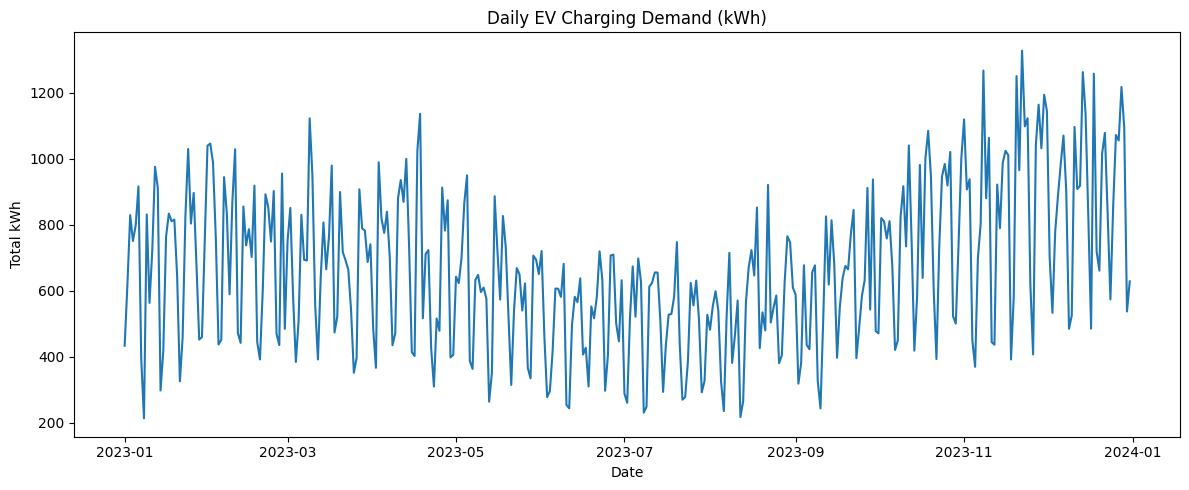

In [ ]:
fig, ax = plt.subplots()
ax.plot(daily.index, daily['kwh_total'])
ax.set_title("Daily EV Charging Demand (kWh)")
ax.set_xlabel("Date")
ax.set_ylabel("Total kWh")
plt.tight_layout()
plt.show()

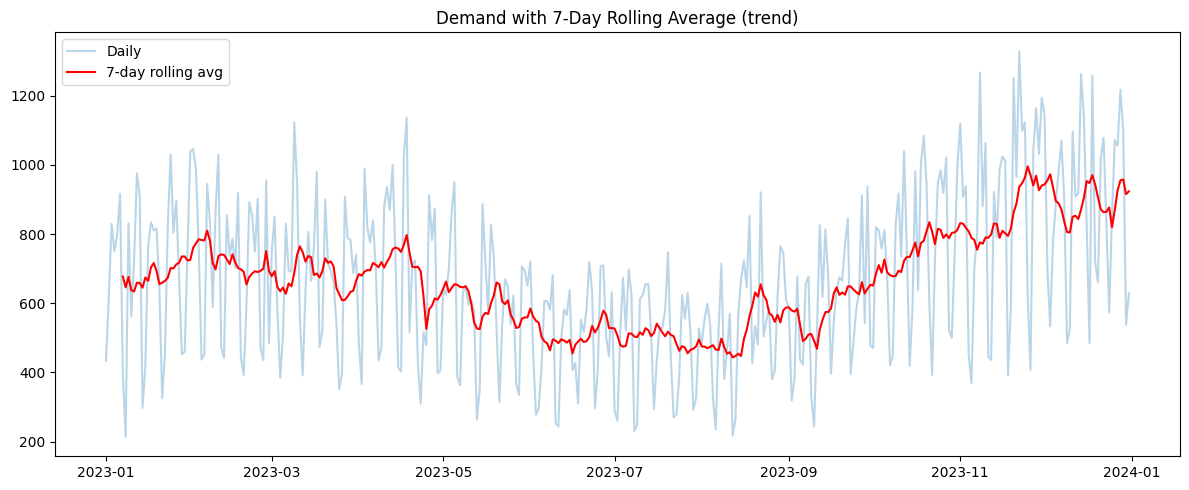

In [ ]:
# 7-day rolling average to see the trend more clearly through the weekly noise
daily['rolling_7d'] = daily['kwh_total'].rolling(7).mean()

fig, ax = plt.subplots()
ax.plot(daily.index, daily['kwh_total'], alpha=0.3, label='Daily')
ax.plot(daily.index, daily['rolling_7d'], color='red', label='7-day rolling avg')
ax.set_title("Demand with 7-Day Rolling Average (trend)")
ax.legend()
plt.tight_layout()
plt.show()

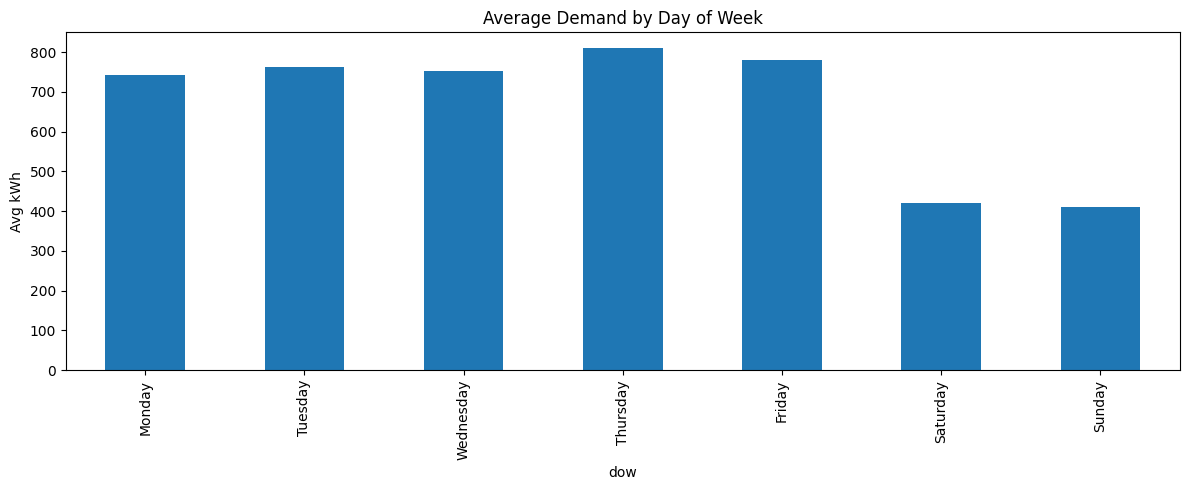

In [ ]:
# Weekly seasonality: average demand by day of week
daily['dow'] = daily.index.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = daily.groupby('dow')['kwh_total'].mean().reindex(dow_order)

fig, ax = plt.subplots()
dow_avg.plot(kind='bar', ax=ax)
ax.set_title("Average Demand by Day of Week")
ax.set_ylabel("Avg kWh")
plt.tight_layout()
plt.show()

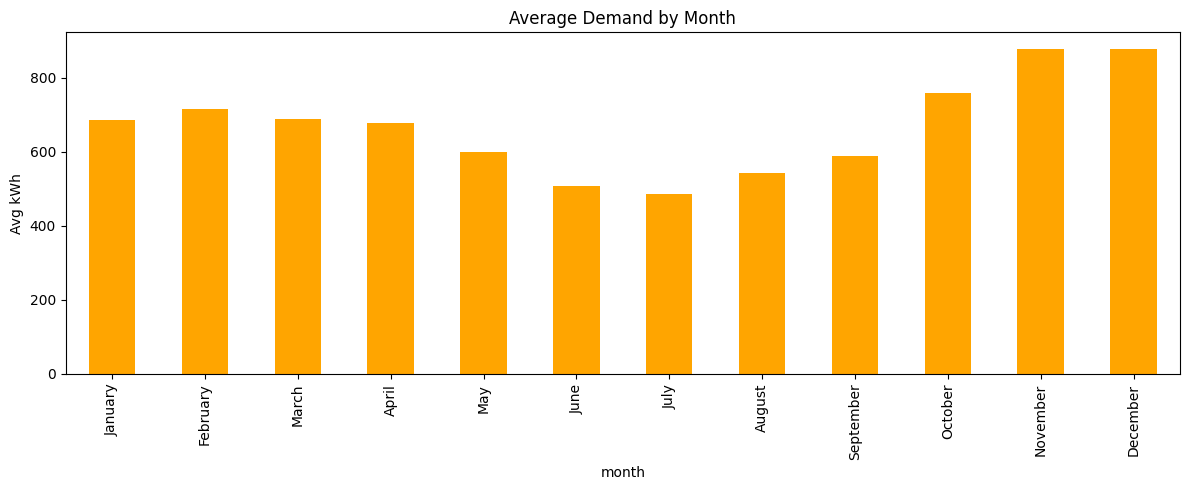

In [ ]:
# Monthly seasonality
daily['month'] = daily.index.month_name()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
month_avg = daily.groupby('month')['kwh_total'].mean().reindex(month_order).dropna()

fig, ax = plt.subplots()
month_avg.plot(kind='bar', ax=ax, color='orange')
ax.set_title("Average Demand by Month")
ax.set_ylabel("Avg kWh")
plt.tight_layout()
plt.show()

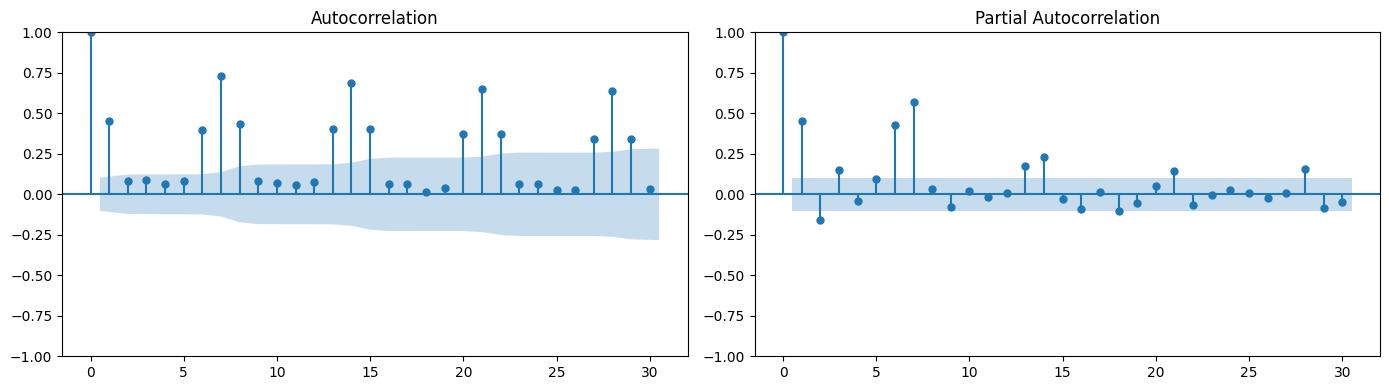

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily['kwh_total'], lags=30, ax=axes[0])
plot_pacf(daily['kwh_total'], lags=30, ax=axes[1])
plt.tight_layout()
plt.show()

## 5. Baseline Model

Train/test split by TIME (never shuffle time series data) — last 30 days held out as the test set.

In [ ]:
series = daily['kwh_total']
test_size = 30
train, test = series[:-test_size], series[-test_size:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

Train: 2023-01-01 to 2023-12-01 (335 days)
Test:  2023-12-02 to 2023-12-31 (30 days)


In [ ]:
# Baseline 1: Seasonal naive (predict using the value from 7 days ago -- captures weekly pattern)
seasonal_naive_pred = series.shift(7)[-test_size:]

# Baseline 2: Simple moving average (last 7 days, rolled forward)
def moving_average_forecast(train_series, horizon, window=7):
    history = list(train_series[-window:])
    preds = []
    for _ in range(horizon):
        next_val = np.mean(history[-window:])
        preds.append(next_val)
        history.append(next_val)
    return preds

ma_pred = pd.Series(moving_average_forecast(train, test_size), index=test.index)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Baseline 3: ARIMA -- order chosen from ACF/PACF plots above as a reasonable starting point
arima_model = ARIMA(train, order=(2, 1, 2))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=test_size)
arima_pred.index = test.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


## 6. Evaluate Baseline

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true.replace(0, np.nan))) * 100
    print(f"{name:20s}  MAE: {mae:8.2f}   RMSE: {rmse:8.2f}   MAPE: {mape:6.2f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []
results.append(evaluate(test, seasonal_naive_pred, "Seasonal Naive"))
results.append(evaluate(test, ma_pred, "Moving Average"))
results.append(evaluate(test, arima_pred, "ARIMA(2,1,2)"))

results_df = pd.DataFrame(results)
results_df

Seasonal Naive        MAE:   177.31   RMSE:   214.19   MAPE:  21.20%
Moving Average        MAE:   232.49   RMSE:   293.65   MAPE:  35.62%
ARIMA(2,1,2)          MAE:   210.23   RMSE:   258.36   MAPE:  31.35%


,model,MAE,RMSE,MAPE
0,Seasonal Naive,177.312082,214.193877,21.197220
1,Moving Average,232.491905,293.647921,35.619758
2,"ARIMA(2,1,2)",210.226820,258.356010,31.348113


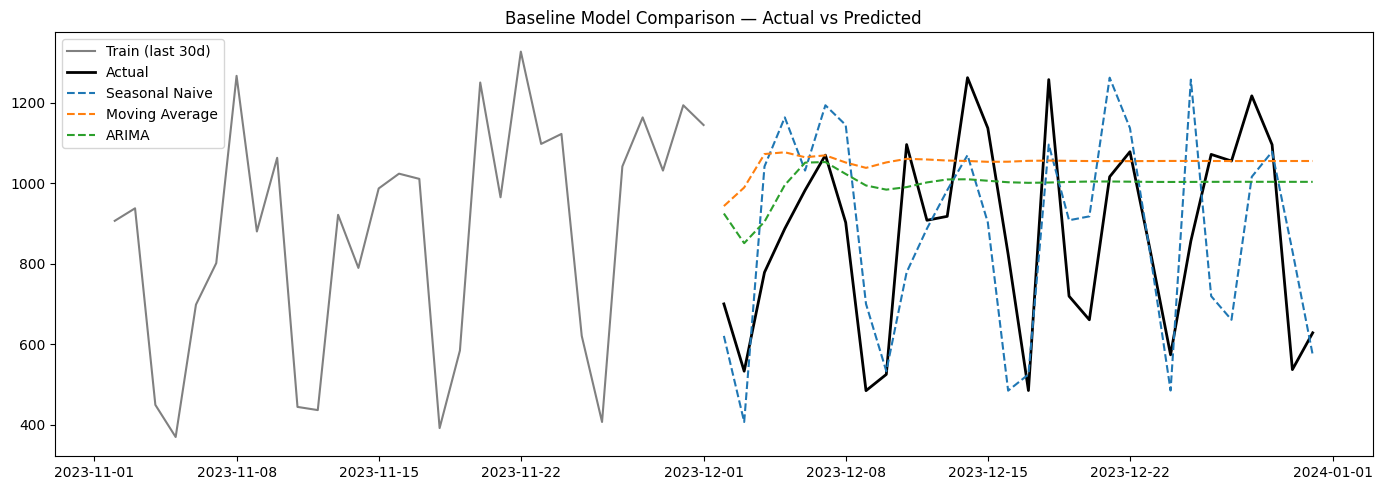

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-30:], train[-30:], label='Train (last 30d)', color='gray')
ax.plot(test.index, test, label='Actual', color='black', linewidth=2)
ax.plot(test.index, seasonal_naive_pred, label='Seasonal Naive', linestyle='--')
ax.plot(test.index, ma_pred, label='Moving Average', linestyle='--')
ax.plot(test.index, arima_pred, label='ARIMA', linestyle='--')
ax.set_title("Baseline Model Comparison — Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Notes — What to Improve Next

*(Fill this in after reviewing the results above — this is your Day 3 "evaluate baseline" deliverable)*

- Which baseline performed best, and why do you think that is?
- Does the residual pattern (actual - predicted) still show structure, or does it look like noise?
- Ideas for the stronger model (Day 4): SARIMA (add explicit seasonal order), Prophet (handles holidays + multiple seasonality out of the box), or a gradient-boosted model (XGBoost/LightGBM) with lag features + day-of-week/month features.


## 8. Stronger Model — SARIMA

The baseline ARIMA doesn't explicitly model the weekly seasonality we saw in the EDA (day-of-week pattern). SARIMA adds a seasonal `(P,D,Q,s)` component on top of ARIMA's `(p,d,q)` — here `s=7` for weekly seasonality.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# order=(p,d,q) non-seasonal part, same as ARIMA baseline
# seasonal_order=(P,D,Q,s) -- s=7 captures the weekly pattern from the EDA
sarima_model = SARIMAX(
    train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=test_size)
sarima_pred.index = test.index

results.append(evaluate(test, sarima_pred, "SARIMA(2,1,2)(1,1,1,7)"))
results_df = pd.DataFrame(results)
results_df

SARIMA(2,1,2)(1,1,1,7)  MAE:   143.56   RMSE:   175.38   MAPE:  19.91%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,model,MAE,RMSE,MAPE
0,Seasonal Naive,177.312082,214.193877,21.197220
1,Moving Average,232.491905,293.647921,35.619758
2,"ARIMA(2,1,2)",210.226820,258.356010,31.348113
3,"SARIMA(2,1,2)(1,1,1,7)",143.562891,175.382735,19.914626


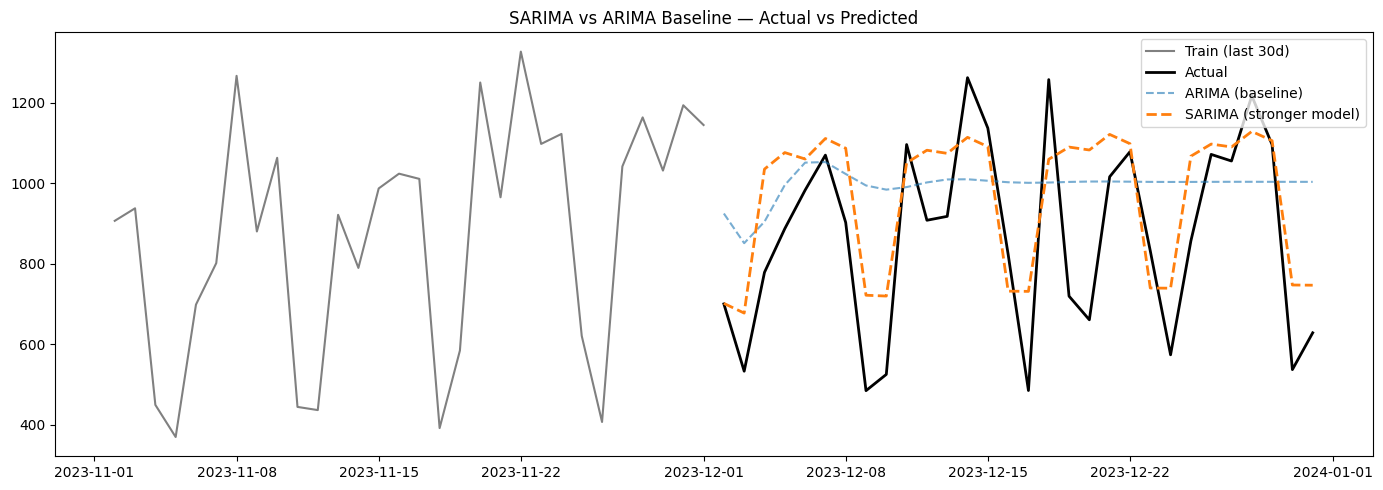

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-30:], train[-30:], label='Train (last 30d)', color='gray')
ax.plot(test.index, test, label='Actual', color='black', linewidth=2)
ax.plot(test.index, arima_pred, label='ARIMA (baseline)', linestyle='--', alpha=0.6)
ax.plot(test.index, sarima_pred, label='SARIMA (stronger model)', linestyle='--', linewidth=2)
ax.set_title("SARIMA vs ARIMA Baseline — Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.show()

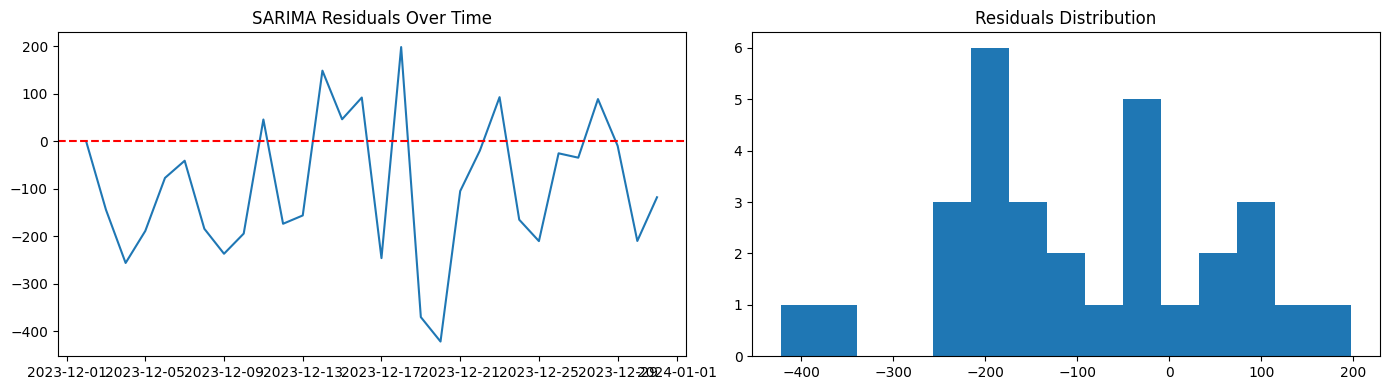

Residual mean: -96.21 (should be close to 0)
Residual std:  149.14


In [ ]:
# Residual diagnostics -- do residuals look like white noise (good) or is there leftover structure (bad)?
residuals = test - sarima_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuals)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("SARIMA Residuals Over Time")

axes[1].hist(residuals, bins=15)
axes[1].set_title("Residuals Distribution")
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.2f} (should be close to 0)")
print(f"Residual std:  {residuals.std():.2f}")

## 9. Final Comparison & Results Summary

*(This table + plot are what goes in your README's Results section)*

In [ ]:
results_df_sorted = results_df.sort_values("RMSE").reset_index(drop=True)
print("Model performance ranked by RMSE (lower is better):\n")
results_df_sorted

Model performance ranked by RMSE (lower is better):



,model,MAE,RMSE,MAPE
0,"SARIMA(2,1,2)(1,1,1,7)",143.562891,175.382735,19.914626
1,Seasonal Naive,177.312082,214.193877,21.197220
2,"ARIMA(2,1,2)",210.226820,258.356010,31.348113
3,Moving Average,232.491905,293.647921,35.619758


### Conclusion

- **Best model:** *(fill in after running — likely SARIMA, since it's the only one modeling weekly seasonality explicitly)*
- **Improvement over baseline:** *(state the % reduction in RMSE/MAPE vs. the seasonal naive baseline)*
- **Remaining limitations:** *(e.g., doesn't account for holidays, external factors like weather or gas prices, or station-level differences — all good "future work" callouts for the README)*